## 📚 Guided Exercise: Implementing Content-Based Filtering on a Books Recommendation Dataset

The aim of this exercise is to implement a content-based filtering system for a books recommendation dataset. The dataset contains information about books, including their titles, authors, genres, and descriptions. The goal is to recommend books to users based on their preferences and the content of the books.

### Step 1: Load the Dataset

Load the dataset into a pandas DataFrame. The dataset is available at [this link](https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset).

There are 3 interesting files in the dataset: 

* books.csv: contains information about the books.
* users.csv: contains information about the users.
* ratings.csv: contains information about the ratings given by the users to the books.

### Step 2: Preprocess the Data

Preprocess the data to make it suitable for content-based filtering. This should include:

* Handling missing values
* Encoding categorical variables
* Creating a content-based feature matrix

### Step 3: Implement Content-Based Filtering

Implement content-based filtering to recommend books to users. This should include:

* Calculating the similarity between books (you can use the system you prefer)
* Recommending books to users based on their preferences

### Step 4: Evaluate the System

Evaluate the performance of the content-based filtering system. This should include:

* Calculating metrics such as precision, recall, and F1-score
* Comparing the performance of the content-based filtering system with at least one other recommendation system.

### Step 5: Visualise the Results

Visualize the results of the content-based filtering system. This should include:

* Creating visualisations to show the performance of the system
* Creating visualisations to show the recommendations made by the system


# Solution

In [1]:
# Import libraries
import pandas as pd

In [2]:
df_books = pd.read_csv("../../../data/books/Books.csv")
df_ratings = pd.read_csv("../../../data/books/Ratings.csv")

/var/folders/pm/331d1kx150j2l4x_h6k6w74c0000gn/T/ipykernel_67702/3863841767.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_books = pd.read_csv("../../../data/books/Books.csv")


In [3]:
from sklearn.model_selection import train_test_split

df_ratings_train, df_ratings_test = train_test_split(
    df_ratings, test_size=0.05, random_state=42
)

In [4]:
len(df_ratings_train), len(df_ratings_test)

(1092291, 57489)

In [5]:
df_books

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


Text(0, 0.5, 'Frequency')

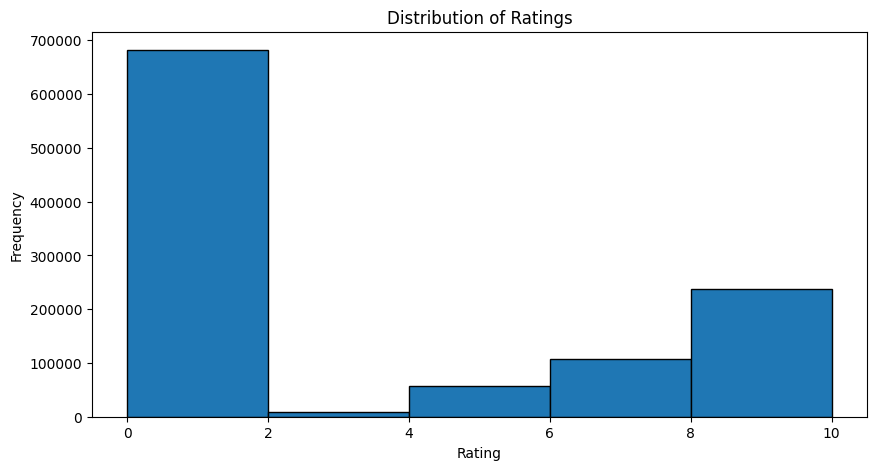

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df_ratings_train["Book-Rating"], bins=5, edgecolor="black")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

In [7]:
df_ratings_train.head()

,User-ID,ISBN,Book-Rating
278613,65665,3458318003,8
291617,69405,042517736X,0
701026,170575,0671742558,0
424135,101209,0743419154,0
91424,20294,0465024769,6


In [8]:
# Distribution of the number of ratings per book
df_ratings_train.groupby("ISBN").size().sort_values(ascending=False).head(10)

ISBN
0971880107    2364
0316666343    1224
0385504209     842
0060928336     697
0312195516     694
044023722X     617
0679781587     604
067976402X     588
0142001740     576
0671027360     559
dtype: int64

<Axes: xlabel='ISBN'>

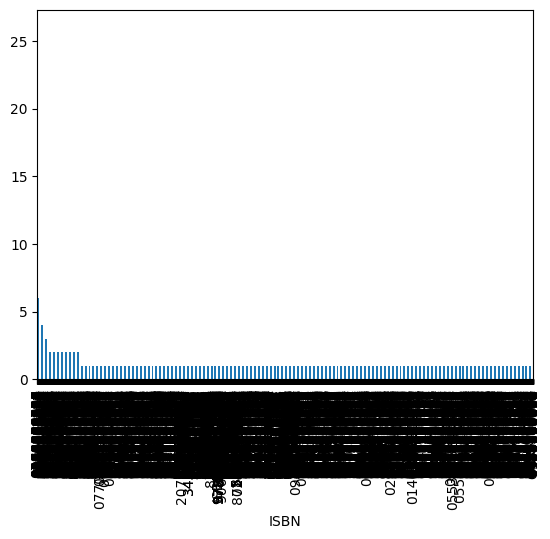

In [19]:
# Histogram of the number of ratings per book
df_ratings_train.sample(10000).groupby("ISBN").size().sort_values(ascending=False).plot(
    kind="bar"
)

In [9]:
# Filter out books with less than 25 ratings
isbns_to_keep = (
    df_ratings_train.groupby("ISBN").size().sort_values(ascending=False) >= 10
)
isbns_to_keep = isbns_to_keep[isbns_to_keep]

In [10]:
df_train_filtered = df_ratings_train[df_ratings_train["ISBN"].isin(isbns_to_keep.index)]
df_train_filtered.head()

,User-ID,ISBN,Book-Rating
291617,69405,042517736X,0
701026,170575,0671742558,0
424135,101209,0743419154,0
190413,41911,034538475X,9
276284,64634,0385336306,6


In [11]:
len(df_train_filtered), len(df_ratings_train)

(500313, 1092291)

<Axes: xlabel='ISBN'>

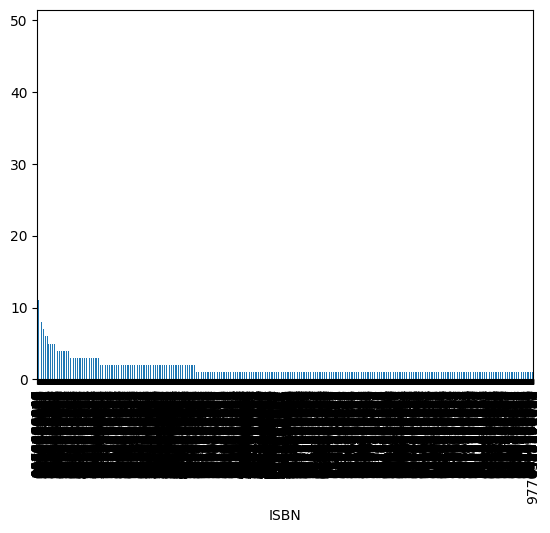

In [ ]:
df_train_filtered.sample(10000).groupby("ISBN").size().sort_values(
    ascending=False
).plot(kind="bar")

Text(0, 0.5, 'Frequency')

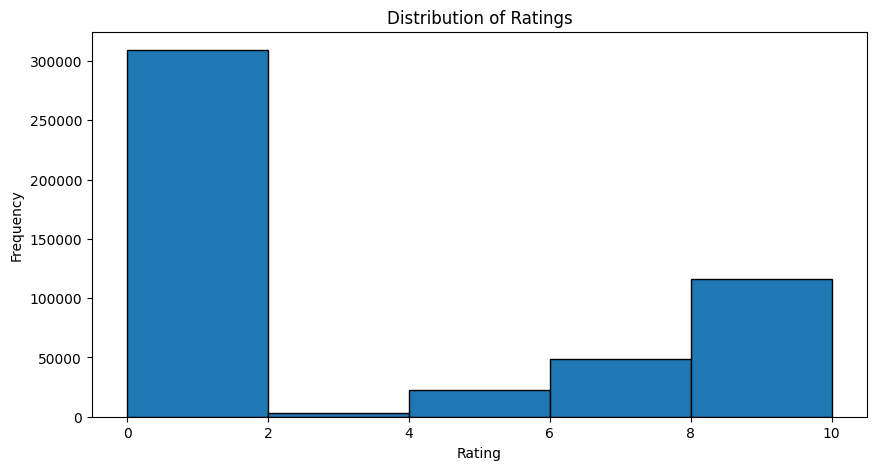

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(df_train_filtered["Book-Rating"], bins=5, edgecolor="black")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

In [13]:
# Balance ratings by downsapmpling the most frequent ratings
df_train_filtered["Book-Rating"] = df_train_filtered["Book-Rating"].apply(
    lambda x: 0 if x < 5 else 5
)
df_train_filtered_zero_rating = df_train_filtered[df_train_filtered["Book-Rating"] == 0]
df_train_filtered_five_rating = df_train_filtered[df_train_filtered["Book-Rating"] == 5]
df_train_filtered_zero_rating = df_train_filtered_zero_rating.sample(
    len(df_train_filtered_five_rating)
)

/var/folders/pm/331d1kx150j2l4x_h6k6w74c0000gn/T/ipykernel_67702/1575159837.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_filtered["Book-Rating"] = df_train_filtered["Book-Rating"].apply(lambda x: 0 if x<5 else 5)


In [ ]:
# Concatenate the two dataframes
df_train_filtered = pd.concat(
    [df_train_filtered_zero_rating, df_train_filtered_five_rating]
)
df_train_filtered.head()
# Shuffle the dataframe
df_train_filtered = df_train_filtered.sample(frac=1).reset_index(drop=True)
df_train_filtered.head()

,User-ID,ISBN,Book-Rating
0,124259,0553279912,0
1,225087,0553250531,5
2,123460,0805062971,5
3,208605,0440221471,0
4,209974,1573221775,5


Text(0, 0.5, 'Frequency')

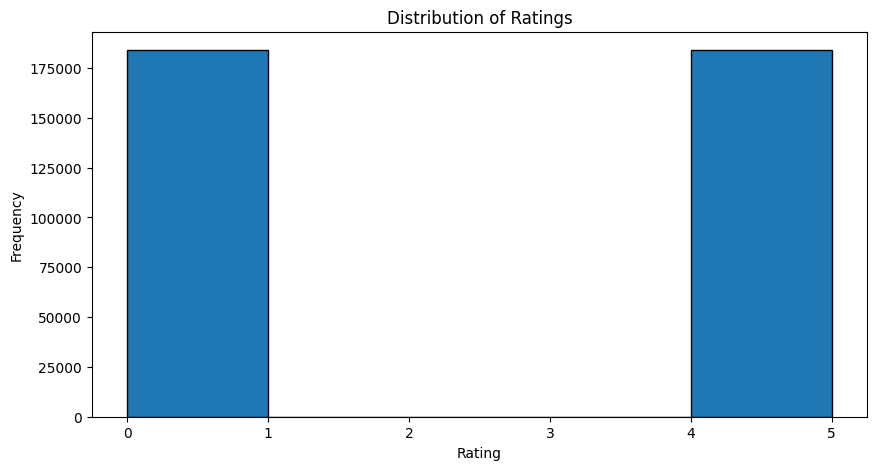

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df_train_filtered["Book-Rating"], bins=5, edgecolor="black")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

In [18]:
# Create a user-item matrix
df_train_filtered = df_train_filtered.pivot_table(
    index="User-ID", columns="ISBN", values="Book-Rating"
)
df_train_filtered.head()
# Fill NaN values with -1
df_train_filtered = df_train_filtered.fillna(-1)
df_train_filtered.head()

ISBN,000000000,0002005018,0002251760,0002255081,0002257203,0002259001,0002259834,0002558122,0006172768,0006374921,...,9724119378,9726101794,9726106141,9726116902,9727591965,9727722458,9728436408,9770390107900,9871138016,9871138148
User-ID,,,,,,,,,,,,,,,,,,,,,
8,-1.0,5.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
9,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
10,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
16,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
17,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [19]:
df_books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [20]:
df_books.drop(columns=["Image-URL-S", "Image-URL-M", "Image-URL-L"], inplace=True)
df_books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company


In [22]:
df_books_filtered = df_books[df_books["ISBN"].isin(df_train_filtered.columns)]
len(df_books_filtered)

16457

In [23]:
len(df_books)

271360

In [24]:
# Transform the book title in capital letters
df_books_filtered["Book-Title"] = df_books_filtered["Book-Title"].str.upper()
df_books_filtered.head()

/var/folders/pm/331d1kx150j2l4x_h6k6w74c0000gn/T/ipykernel_67702/1024020673.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_books_filtered["Book-Title"] = df_books_filtered["Book-Title"].str.upper()


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
1,0002005018,CLARA CALLAN,Richard Bruce Wright,2001,HarperFlamingo Canada
3,0374157065,FLU: THE STORY OF THE GREAT INFLUENZA PANDEMIC...,Gina Bari Kolata,1999,Farrar Straus Giroux
5,0399135782,THE KITCHEN GOD'S WIFE,Amy Tan,1991,Putnam Pub Group
18,0440234743,THE TESTAMENT,John Grisham,1999,Dell
19,0452264464,BELOVED (PLUME CONTEMPORARY FICTION),Toni Morrison,1994,Plume


In [44]:
# Use TF-IDF to create a document-term matrix on the title column
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=1000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df_books_filtered["Book-Title"])
tfidf_matrix.shape

(16457, 1000)

In [27]:
from sklearn.preprocessing import OneHotEncoder

# Keep only the Author last name
df_books_filtered["Book-Author"] = (
    df_books_filtered["Book-Author"].str.split().str[-1].str.upper()
)
df_books_filtered.head()
# One-hot encode the author column

onehot = OneHotEncoder()
onehot_matrix = onehot.fit_transform(df_books_filtered[["Book-Author"]])
onehot_matrix.shape

/var/folders/pm/331d1kx150j2l4x_h6k6w74c0000gn/T/ipykernel_67702/551098531.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_books_filtered["Book-Author"] = df_books_filtered["Book-Author"].str.split().str[-1].str.upper()


(16457, 3305)

In [ ]:
# Impute the missing values with the mean of published year
df_books_filtered["Year-Of-Publication"] = df_books_filtered[
    "Year-Of-Publication"
].astype(int)
df_books_filtered["Year-Of-Publication"] = df_books_filtered[
    "Year-Of-Publication"
].fillna(df_books_filtered["Year-Of-Publication"].mean())
df_books_filtered.head()

/var/folders/pm/331d1kx150j2l4x_h6k6w74c0000gn/T/ipykernel_67702/3627958109.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_books_filtered["Year-Of-Publication"] = df_books_filtered["Year-Of-Publication"].astype(int)
/var/folders/pm/331d1kx150j2l4x_h6k6w74c0000gn/T/ipykernel_67702/3627958109.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_books_filtered["Year-Of-Publication"] = df_books_filtered["Year-Of-Publication"].fillna(df_books_filtered["Year-Of-Publication"].mean())


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
1,0002005018,CLARA CALLAN,WRIGHT,2001,HarperFlamingo Canada
3,0374157065,FLU: THE STORY OF THE GREAT INFLUENZA PANDEMIC...,KOLATA,1999,Farrar Straus Giroux
5,0399135782,THE KITCHEN GOD'S WIFE,TAN,1991,Putnam Pub Group
18,0440234743,THE TESTAMENT,GRISHAM,1999,Dell
19,0452264464,BELOVED (PLUME CONTEMPORARY FICTION),MORRISON,1994,Plume


In [ ]:
# Compose vectors for each book (title, author, year) concatenating numpy arrays
import numpy as np

Book_vectors = np.concatenate(
    [
        tfidf_matrix.toarray(),
        onehot_matrix.toarray(),
        df_books_filtered["Year-Of-Publication"].values.reshape(-1, 1),
    ],
    axis=1,
)
Book_vectors.shape

(16457, 4306)

In [41]:
# Calculate the cosine similarity between the book vectors
from sklearn.metrics.pairwise import cosine_similarity

cosine_matrix = cosine_similarity(Book_vectors)

In [42]:
# Recommend the top 5 books for a given book
def recommend_books(book_title, cosine_matrix, df_books_filtered):
    # Get the index of the book
    book_index = df_books_filtered[df_books_filtered["Book-Title"] == book_title].index[
        0
    ]
    # Get the cosine similarity between the book and all other books
    cosine_similarity_scores = cosine_matrix[book_index]
    # Get the top 5 books
    top_5_books = cosine_similarity_scores.argsort()[-5:][::-1]
    return df_books_filtered.iloc[top_5_books]


recommend_books("THE GREAT GATSBY", cosine_matrix, df_books_filtered)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
8749,0440219507,TROUBLING A STAR,L'ENGLE,1995,Laure Leaf
18903,0440952522,MANY WATERS,L'ENGLE,1987,Laurel Leaf
53368,0440405483,MANY WATERS,L'ENGLE,1987,Yearling Books
94057,0451458893,"STAR RISK, LTD. (STAR RISK, 1)",BUNCH,2002,Roc
14450,0373484895,CAPTIVE STAR,ROBERTS,2001,Silhouette
